# Informe Final: Resumen del Barrido de Hipótesis Delta (V38)

## 1. Tabla Comparativa de Resultados (Ordenada por Delta)

A continuación se presenta el resumen integral del testeo de sensibilidad. Esta tabla es la base para la toma de decisiones sobre el "Sweet Spot" de la estrategia.

| Delta (pts) | Profit Total (R) | Nº Trades | Win Rate (%) | Expectancy (R) | Sortino | Profit Factor | Max DD (R) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **0.0** | 104.61 R | 1281 | 24.98% | 0.082 R | 1.64 | 1.19 | -20.00 R |
| **5.0** | 175.49 R | 1265 | 26.09% | 0.139 R | 2.65 | 1.36 | -15.00 R |
| **7.5** | 163.64 R | 1129 | 26.48% | 0.145 R | 2.62 | 1.37 | -16.00 R |
| **10.0** | 146.64 R | 1000 | 27.00% | 0.147 R | 2.52 | 1.37 | -12.00 R |
| **15.0** | 101.41 R | 795 | 26.16% | 0.128 R | 1.97 | 1.32 | -14.00 R |
| **20.0** | 91.92 R | 666 | 26.58% | 0.138 R | 1.94 | 1.35 | -12.00 R |
| **25.0** | 82.55 R | 577 | 27.04% | 0.143 R | 1.89 | 1.36 | -13.00 R |
| **30.0** | 82.78 R | 512 | 27.73% | 0.162 R | 2.00 | 1.41 | -10.62 R |
| **35.0** | 78.76 R | 439 | 28.25% | 0.179 R | 2.04 | 1.46 | -12.23 R |

## 2. Análisis de Hallazgos

* **Pico de Retorno Absoluto:** El **Delta 5.0** maximiza el beneficio total con 175.49R. Es el motor de crecimiento más potente, pero con mayor carga operativa.
* **Eficiencia de Marea (Expectancy):** A medida que aumentamos el Delta hacia **35.0**, la esperanza matemática por trade sube a **0.179R**. Esto confirma que esperar confirmaciones más largas limpia "ruido", aunque reduce el universo de trades en un ~65% respecto al baseline.
* **Zona de Estabilidad (Sweet Spot):** Entre **Delta 7.5 y 10.0** se encuentra el equilibrio ideal. El Ratio de Sortino se mantiene por encima de 2.5 y el Profit Factor es constante (~1.37), ofreciendo una curva de capital más suave.

## 3. Conclusión Estratégica
Aunque el **Delta 35** ofrece el Profit Factor más alto (1.46), la caída en el número de trades es demasiado severa para el objetivo de crecimiento. Se mantiene el **Delta 5.0 como Baseline** para la implementación de los filtros de Marea y Centinela, con el fin de no perder la frecuencia necesaria para que estos filtros actúen sobre una muestra representativa.
Indicadores Baseline
| Delta (pts) | Profit Total (R) | Nº Trades | Win Rate (%) | Expectancy (R) | Sortino | Profit Factor | Max DD (R) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **5.0** | 175.49 R | 1265 | 26.09% | 0.139 R | 2.65 | 1.36 | -15.00 R |

## 4. Justificación del Trade-off Seleccionado

Se ha decidido mantener el Delta = 5.0 como base para las siguientes fases de desarrollo, basándonos en los siguientes principios:

Preservación del Universo de Datos: Al ser el Delta que más trades genera (dentro de un marco lógico), ofrece una muestra estadística superior para entrenar el Filtro Centinela.

Soberanía de los Filtros Posteriores: La lógica de "Marea" (EMA H1) y "Centinela" (Régimen) está diseñada para hacer el trabajo que actualmente hace el "Delta Alto" (filtrar trades malos). Es preferible filtrar por contexto de mercado que por distancia fija de puntos.

Evitar la Inanición Operativa: Aplicar un Delta 15 junto con filtros de tendencia y volatilidad podría reducir la operativa a niveles insuficientes para cubrir costes fijos o cumplir objetivos de volumen.

Loop de Re-evaluación: Una vez activos los niveles de filtrado anteriores, se repetirá este barrido de Delta. La hipótesis es que un Delta bajo (5.0) ganará por goleada al operar solo en entornos de alta probabilidad.

In [1]:
import pandas as pd
import numpy as np
import warnings

# Configuración de rutas
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

def capa_0_datos(path):
    """
    Capa 0: Carga, Warm-up de indicadores y Filtrado de Sesión.
    """
    # Silenciamos advertencias de frecuencia si fuera necesario, 
    # aunque lo corregiremos directamente en el código.
    print(f"🚀 Cargando dataset desde: {path}")
    
    # 1. Carga del archivo Parquet
    df = pd.read_parquet(path)
    df.index = pd.to_datetime(df.index)
    
    # Asegurar que el índice sea local (NY) y sin zona horaria para cálculos rápidos
    if df.index.tz is not None:
        df.index = df.index.tz_convert('America/New_York').tz_localize(None)
    
    # 2. Cálculo de EMAs sobre el dataset COMPLETO (Warm-up)
    
    # EMAs de 1 Minuto
    periodos_1m = [1, 9, 12, 21, 50]
    for p in periodos_1m:
        df[f'EMA_1m_{p}'] = df['Close'].ewm(span=p, adjust=False).mean()
        
    # EMAs de 1 Hora (Estructurales)
    # Corrección de Warning: usamos '1h' en lugar de '1H'
    df_1h = df.resample('1h').last().copy()
    periodos_1h = [20, 50, 100, 200]
    for p in periodos_1h:
        df_1h[f'EMA_1h_{p}'] = df_1h['Close'].ewm(span=p, adjust=False).mean()
    
    # Desplazamos 1 periodo las EMAs de 1h para usar solo info CERRADA
    # Nota: Esto genera NaNs en el primer registro histórico de la base de datos
    df_1h_shifted = df_1h[[f'EMA_1h_{p}' for p in periodos_1h]].shift(1)
    
    # Unir EMAs 1h al dataframe principal
    df = df.join(df_1h_shifted, how='left')
    df[[f'EMA_1h_{p}' for p in periodos_1h]] = df[[f'EMA_1h_{p}' for p in periodos_1h]].ffill()
    
    # 3. Filtrado de Sesión Operativa
    # Recortamos el dataframe para el backtest (09:30 a 18:00)
    df_session = df.between_time('09:30', '18:00').copy()
    
    # Limpieza de registros iniciales sin indicadores calculados (NaNs de la EMA 200h)
    # Esto elimina los primeros días del historial donde la EMA200h aún no existe.
    df_session = df_session.dropna(subset=[f'EMA_1h_200'])
    
    print(f"✅ Capa 0 Completada (Warning corregido y NaNs filtrados).")
    print(f"Velas procesadas: {len(df_session)}")
    print(f"Rango operativo real: {df_session.index.min()} a {df_session.index.max()}")
    
    return df_session

# --- EJECUCIÓN ---
df_ready = capa_0_datos(FILE_PATH_PARQUET)
df_ready.head()

🚀 Cargando dataset desde: /home/quant/data/processed/nq_1m_continuous.parquet
✅ Capa 0 Completada (Warning corregido y NaNs filtrados).
Velas procesadas: 1738894
Rango operativo real: 2010-06-07 09:30:00 a 2025-12-12 16:59:00


,Open,High,Low,Close,Volume,Ticker,EMA_1m_1,EMA_1m_9,EMA_1m_12,EMA_1m_21,EMA_1m_50,EMA_1h_20,EMA_1h_50,EMA_1h_100,EMA_1h_200
timestamp,,,,,,,,,,,,,,,
2010-06-07 09:30:00,1841.25,1842.00,1838.75,1841.00,3113,NQM0,1841.00,1840.032226,1839.864509,1839.805139,1840.221120,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:31:00,1840.75,1843.75,1840.50,1842.75,1596,NQM0,1842.75,1840.575781,1840.308431,1840.072854,1840.320292,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:32:00,1842.75,1844.25,1841.50,1843.75,1377,NQM0,1843.75,1841.210625,1840.837903,1840.407140,1840.454791,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:33:00,1843.75,1844.00,1839.50,1839.50,1274,NQM0,1839.50,1840.868500,1840.632072,1840.324672,1840.417348,1827.324773,1823.387119,1821.781056,1820.913594
2010-06-07 09:34:00,1839.50,1840.75,1837.00,1837.75,1566,NQM0,1837.75,1840.244800,1840.188676,1840.090611,1840.312746,1827.324773,1823.387119,1821.781056,1820.913594


In [2]:
import pandas as pd
import numpy as np

def generar_trades_orb(df, breakout_delta=5.0):
    """
    Capa 1: Lógica de detección de ORB, confirmación de Breakout y ejecución en Midpoint.
    Limitado a 1 trade por día.
    """
    print(f"distancia de confirmación (BreakoutDelta): {breakout_delta} puntos.")
    
    # 1. Identificar días únicos en el dataset
    df['date'] = df.index.date
    unique_days = df['date'].unique()
    trades = []

    for day in unique_days:
        # Filtrar data del día
        df_day = df[df['date'] == day].copy()
        
        # 2. Definir el Rango ORB (09:30 - 09:34 inclusive)
        # Las primeras 5 velas de 1m definen el rango de 5m
        orb_data = df_day.between_time('09:30', '09:34')
        if len(orb_data) < 5:
            continue
            
        orb_h = orb_data['High'].max()
        orb_l = orb_data['Low'].min()
        orb_m = (orb_h + orb_l) / 2
        
        # 3. Buscar Confirmación de Breakout (Post 09:34)
        # Solo evaluamos velas a partir de las 09:35
        post_orb = df_day.between_time('09:35', '16:00')
        
        confirmed_dir = None
        confirmation_time = None
        
        for ts, row in post_orb.iterrows():
            # Condición Long: Vela completa a distancia Delta sobre el High
            if row['Low'] >= (orb_h + breakout_delta):
                confirmed_dir = 'Long'
                confirmation_time = ts
                break
            
            # Condición Short: Vela completa a distancia Delta bajo el Low
            if row['High'] <= (orb_l - breakout_delta):
                confirmed_dir = 'Short'
                confirmation_time = ts
                break
        
        # 4. Si hay confirmación, buscar Retest al Midpoint
        if confirmed_dir:
            # Buscamos la entrada desde el minuto siguiente a la confirmación
            retest_data = post_orb.loc[confirmation_time:].iloc[1:]
            
            entry_time = None
            entry_price = orb_m
            
            for ts_entry, row_entry in retest_data.iterrows():
                # El precio debe cruzar o tocar el midpoint para gatillar
                if confirmed_dir == 'Long':
                    # En un Long, venimos de arriba, buscamos Low <= Midpoint
                    if row_entry['Low'] <= orb_m:
                        entry_time = ts_entry
                        break
                else:
                    # En un Short, venimos de abajo, buscamos High >= Midpoint
                    if row_entry['High'] >= orb_m:
                        entry_time = ts_entry
                        break
            
            # 5. Registrar el Trade si hubo entrada
            if entry_time:
                # Valores adicionales importantes para optimización
                trade_info = {
                    'fecha': day,
                    'orb_high': orb_h,
                    'orb_low': orb_l,
                    'midpoint': orb_m,
                    'direccion': confirmed_dir,
                    'confirmacion_dt': confirmation_time,
                    'entrada_dt': entry_time,
                    'entrada_precio': entry_price,
                    # Referencias de mercado al momento de entrada
                    'ema_1h_50_entry': row_entry['EMA_1h_50'],
                    'ema_1m_21_entry': row_entry['EMA_1m_21'],
                    'ticker': row_entry['Ticker']
                }
                trades.append(trade_info)
                # Req Inmutable: Solo 1 trade al día. Pasamos al siguiente día.
                continue

    # Convertir a DataFrame de Trades
    df_trades = pd.DataFrame(trades)
    
    if not df_trades.empty:
        df_trades['entrada_dt'] = pd.to_datetime(df_trades['entrada_dt'])
        print(f"✅ Procesamiento completado. Trades generados: {len(df_trades)}")
    else:
        print("⚠️ No se generaron trades con los parámetros actuales.")
        
    return df_trades

# --- EJECUCIÓN ---
# Nota: df_ready viene de la Capa 0
df_trades_raw = generar_trades_orb(df_ready, breakout_delta=5.0)
df_trades_raw.head()

distancia de confirmación (BreakoutDelta): 5.0 puntos.
✅ Procesamiento completado. Trades generados: 2385


,fecha,orb_high,orb_low,midpoint,direccion,confirmacion_dt,entrada_dt,entrada_precio,ema_1h_50_entry,ema_1m_21_entry,ticker
0,2010-06-07,1844.25,1837.00,1840.625,Short,2010-06-07 09:43:00,2010-06-07 09:53:00,1840.625,1823.387119,1835.366356,NQM0
1,2010-06-08,1803.50,1796.50,1800.000,Short,2010-06-08 09:54:00,2010-06-08 11:57:00,1800.000,1810.597340,1794.184535,NQM0
2,2010-06-09,1808.75,1804.75,1806.750,Short,2010-06-09 10:05:00,2010-06-09 10:51:00,1806.750,1799.436594,1801.177908,NQM0
3,2010-06-10,1809.25,1801.00,1805.125,Long,2010-06-10 10:01:00,2010-06-10 12:44:00,1805.125,1796.663916,1808.125132,NQM0
4,2010-06-14,1864.25,1859.50,1861.875,Long,2010-06-14 10:17:00,2010-06-14 13:07:00,1861.875,1841.323032,1865.321516,NQU0


In [3]:
import pandas as pd
import numpy as np

def simular_gestion_riesgo(df_ready, df_trades, breakout_delta=5.0):
    """
    Capa 2: Simulación de gestión de riesgo con modelo secuencial OHLC/OLHC.
    Salidas: TP (2R), SL (Extremo ORB), BE (al tocar 1R).
    """
    print(f"🚀 Iniciando gestión de riesgo para {len(df_trades)} trades...")
    
    resultados = []

    for _, trade in df_trades.iterrows():
        # Extraer parámetros del trade
        entry_price = trade['entrada_precio']
        direction = trade['direccion']
        orb_h = trade['orb_high']
        orb_l = trade['orb_low']
        
        # Calcular distancias de riesgo (R)
        # R es la distancia del midpoint al extremo del ORB
        risk_r = abs(entry_price - (orb_l if direction == 'Long' else orb_h))
        
        stop_loss = orb_l if direction == 'Long' else orb_h
        take_profit = entry_price + (2 * risk_r) if direction == 'Long' else entry_price - (2 * risk_r)
        be_trigger = entry_price + risk_r if direction == 'Long' else entry_price - risk_r
        
        # Obtener data desde el minuto de entrada hasta el fin de sesión
        df_day = df_ready[df_ready.index.date == trade['fecha']]
        df_post_entry = df_day.loc[trade['entrada_dt']:]
        
        current_sl = stop_loss
        be_activated = False
        exit_price = None
        exit_time = None
        exit_reason = None
        
        for ts, row in df_post_entry.iterrows():
            # Modelo Secuencial OHLC/OLHC para resolver conflictos intra-vela
            if row['Open'] <= row['Close']:
                # Vela Alcista: Open -> Low -> High -> Close
                sequence = [row['Open'], row['Low'], row['High'], row['Close']]
            else:
                # Vela Bajista: Open -> High -> Low -> Close
                sequence = [row['Open'], row['High'], row['Low'], row['Close']]
                
            for price_point in sequence:
                # 1. Verificar Trigger de Break Even (1R)
                if not be_activated:
                    if (direction == 'Long' and price_point >= be_trigger) or \
                       (direction == 'Short' and price_point <= be_trigger):
                        current_sl = entry_price
                        be_activated = True
                
                # 2. Verificar Stop Loss (o BE si ya se activó)
                if (direction == 'Long' and price_point <= current_sl) or \
                   (direction == 'Short' and price_point >= current_sl):
                    exit_price = current_sl
                    exit_time = ts
                    exit_reason = 'SL' if not be_activated else 'BE'
                    break
                
                # 3. Verificar Take Profit (2R)
                if (direction == 'Long' and price_point >= take_profit) or \
                   (direction == 'Short' and price_point <= take_profit):
                    exit_price = take_profit
                    exit_time = ts
                    exit_reason = 'TP'
                    break
            
            if exit_time: break
            
        # 4. Cierre forzado EOD si no salió por niveles
        if not exit_time:
            exit_price = df_post_entry['Close'].iloc[-1]
            exit_time = df_post_entry.index[-1]
            exit_reason = 'EOD'

        # Cálculo de PnL en R
        pnl_r = (exit_price - entry_price) / risk_r if direction == 'Long' else (entry_price - exit_price) / risk_r
        
        # Guardar resultado extendido
        res = trade.to_dict()
        res.update({
            'salida_dt': exit_time,
            'salida_precio': exit_price,
            'motivo': exit_reason,
            'pnl_r': pnl_r,
            'be_activado': be_activated,
            'risk_r_puntos': risk_r
        })
        resultados.append(res)

    df_results = pd.DataFrame(resultados)
    print(f"✅ Gestión completada. Win Rate: {(df_results['pnl_r'] > 0).mean():.2%}")
    return df_results

# --- EJECUCIÓN ---
# df_ready (Capa 0) y df_trades_raw (Capa 1) deben estar en memoria
df_final_results = simular_gestion_riesgo(df_ready, df_trades_raw)
df_final_results[['fecha', 'direccion', 'motivo', 'pnl_r']].head(10)

🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%


,fecha,direccion,motivo,pnl_r
0,2010-06-07,Short,SL,-1.0
1,2010-06-08,Short,TP,2.0
2,2010-06-09,Short,BE,0.0
3,2010-06-10,Long,TP,2.0
4,2010-06-14,Long,BE,0.0
5,2010-06-17,Short,TP,2.0
6,2010-06-18,Long,SL,-1.0
7,2010-06-22,Long,BE,0.0
8,2010-06-23,Short,SL,-1.0
9,2010-06-24,Short,SL,-1.0


📊 Generando reporte de evaluación...
🔒 Filtrando trades por ventanas: 10-11, 12-13, 14-15...
------------------------------
📈 REPORTE DE PERFORMANCE (V38)
------------------------------
Total Trades:      1265
Win Rate:          26.56%
BE Rate:           34.62%
Loss Rate:         38.81%
Expectancy:        0.14 R
Profit Factor:     1.36
Max Drawdown:      -15.00 R
Resultado Final:   175.49 R
------------------------------


/tmp/ipykernel_42344/3822163333.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dia_semana', y='pnl_r', data=df_results, order=order, ax=axes[1, 0], palette='viridis')


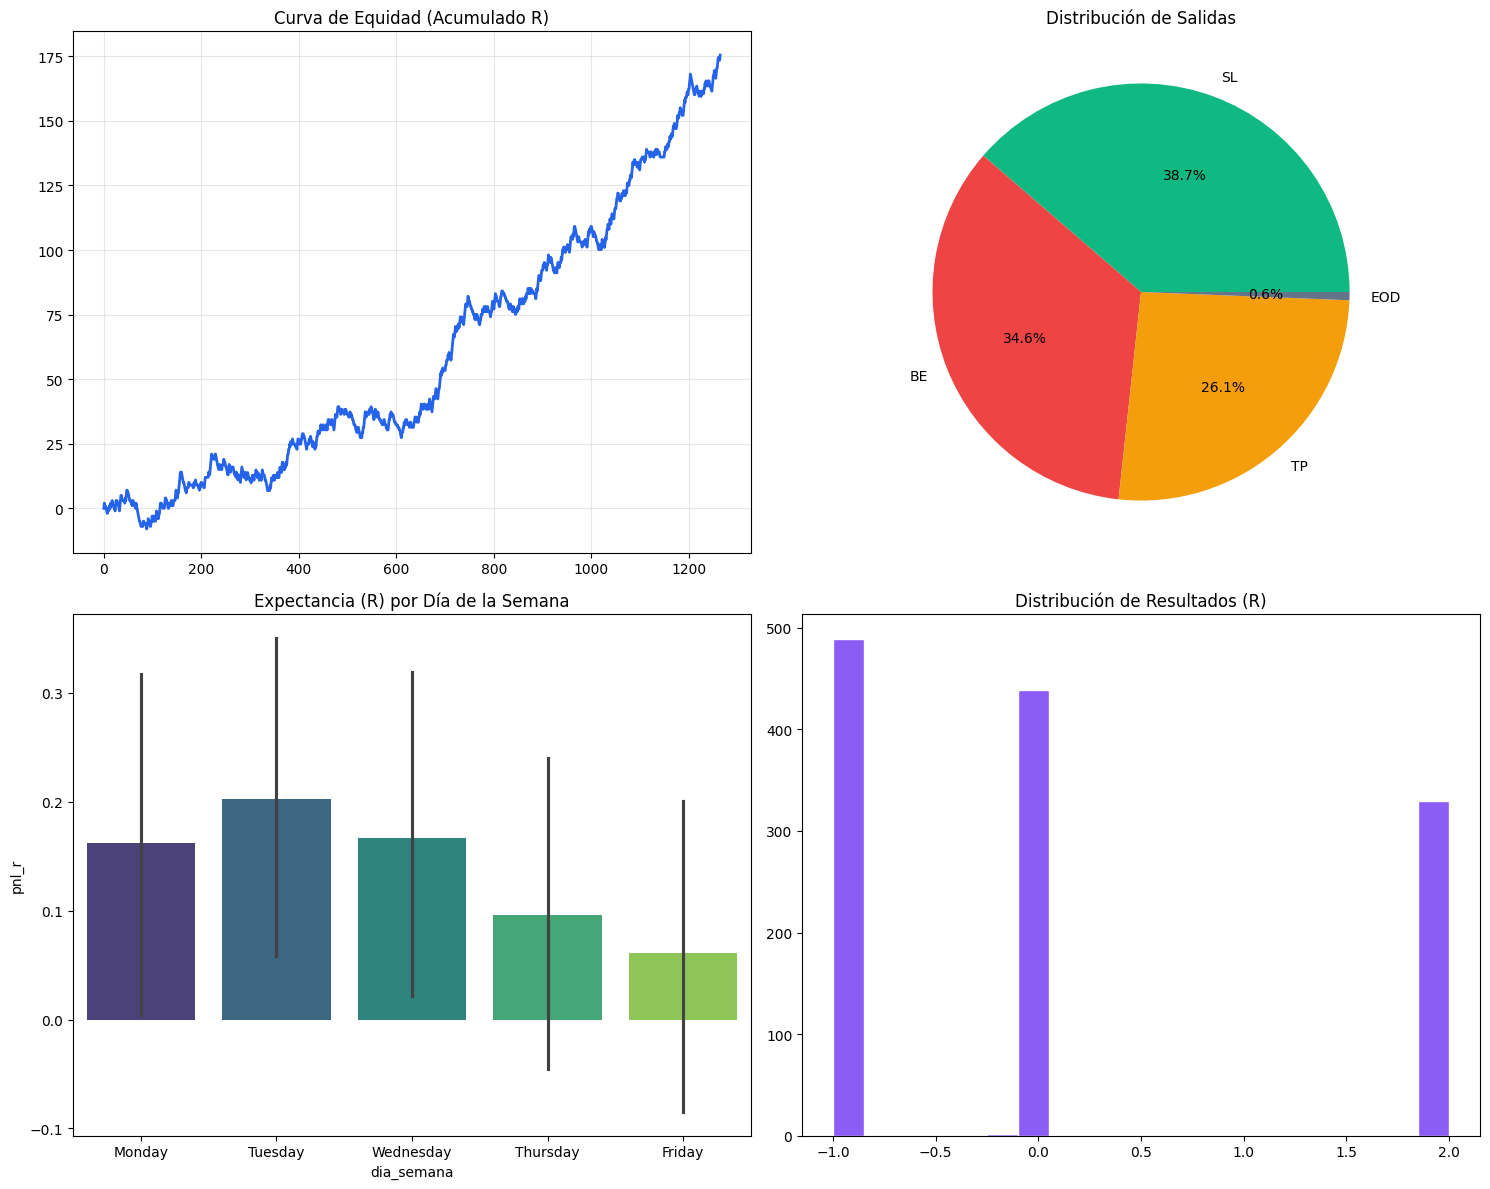

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluar_estrategia(df_results):
    """
    Capa 4: Evaluación de métricas, análisis estadístico y visualización.
    Modificado para cumplir con REQ-EXEC-002 (Ventanas Operativas).
    """
    print("📊 Generando reporte de evaluación...")
    
    # --- FILTRO DE VENTANAS OPERATIVAS (REQ-EXEC-002) ---
    def esta_en_ventana(hora_str):
        h, m = map(int, hora_str.split(':'))
        t = h * 60 + m
        # 10:00-11:00 (600-660), 12:00-13:00 (720-780), 14:00-15:00 (840-900)
        ventanas = [(600, 660), (720, 780), (840, 900)]
        return any(inicio <= t < fin for inicio, fin in ventanas)

    if 'hora_entrada' not in df_results.columns:
        # Intentar extraer hora si no existe la columna pero sí el datetime
        df_results['hora_entrada'] = pd.to_datetime(df_results['entrada_dt']).dt.strftime('%H:%M')

    print("🔒 Filtrando trades por ventanas: 10-11, 12-13, 14-15...")
    df_results = df_results[df_results['hora_entrada'].apply(esta_en_ventana)].copy()

    if df_results.empty:
        print("⚠️ No hay trades que cumplan con las ventanas operativas.")
        return df_results

    # 1. Cálculos de Retorno Acumulado
    df_results = df_results.sort_values('fecha').copy()
    df_results['pnl_acumulado'] = df_results['pnl_r'].cumsum()
    
    # 2. Métricas Clave
    total_trades = len(df_results)
    win_rate = (df_results['pnl_r'] > 0).mean()
    be_rate = (df_results['pnl_r'] == 0).mean()
    loss_rate = (df_results['pnl_r'] < 0).mean()
    
    ganancia_total = df_results[df_results['pnl_r'] > 0]['pnl_r'].sum()
    perdida_total = abs(df_results[df_results['pnl_r'] < 0]['pnl_r'].sum())
    profit_factor = ganancia_total / perdida_total if perdida_total != 0 else np.inf
    
    expectancy = df_results['pnl_r'].mean() # Esperanza matemática por trade en R
    
    # Drawdown en R
    rolling_max = df_results['pnl_acumulado'].cummax()
    drawdown = df_results['pnl_acumulado'] - rolling_max
    max_drawdown = drawdown.min()
    
    # 3. Impresión de Reporte
    print("-" * 30)
    print(f"📈 REPORTE DE PERFORMANCE (V38)")
    print("-" * 30)
    print(f"Total Trades:      {total_trades}")
    print(f"Win Rate:          {win_rate:.2%}")
    print(f"BE Rate:           {be_rate:.2%}")
    print(f"Loss Rate:         {loss_rate:.2%}")
    print(f"Expectancy:        {expectancy:.2f} R")
    print(f"Profit Factor:     {profit_factor:.2f}")
    print(f"Max Drawdown:      {max_drawdown:.2f} R")
    print(f"Resultado Final:   {df_results['pnl_acumulado'].iloc[-1]:.2f} R")
    print("-" * 30)

    # 4. Visualización
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # A. Curva de Equidad
    axes[0, 0].plot(range(len(df_results)), df_results['pnl_acumulado'], color='#2563eb', lw=2)
    axes[0, 0].set_title("Curva de Equidad (Acumulado R)")
    axes[0, 0].grid(alpha=0.3)
    
    # B. Distribución de Motivos de Salida
    motivo_counts = df_results['motivo'].value_counts()
    axes[0, 1].pie(motivo_counts, labels=motivo_counts.index, autopct='%1.1f%%', 
                  colors=['#10b981', '#ef4444', '#f59e0b', '#64748b'])
    axes[0, 1].set_title("Distribución de Salidas")
    
    # C. PnL por Día de la Semana
    df_results['dia_semana'] = pd.to_datetime(df_results['fecha']).dt.day_name()
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
    sns.barplot(x='dia_semana', y='pnl_r', data=df_results, order=order, ax=axes[1, 0], palette='viridis')
    axes[1, 0].set_title("Expectancia (R) por Día de la Semana")
    
    # D. Histograma de PnL
    axes[1, 1].hist(df_results['pnl_r'], bins=20, color='#8b5cf6', edgecolor='white')
    axes[1, 1].set_title("Distribución de Resultados (R)")
    
    plt.tight_layout()
    plt.show()
    
    return df_results

# --- EJECUCIÓN ---
# df_final_results debe ser el DataFrame generado por la Capa 2
df_evaluado = evaluar_estrategia(df_final_results)

🧪 Iniciando Prueba de Hipótesis: Sensibilidad del Breakout Delta
📊 Baseline Objetivo: 175.49 R (Delta = 5.0)
------------------------------------------------------------
distancia de confirmación (BreakoutDelta): 0 puntos.
✅ Procesamiento completado. Trades generados: 2956
🚀 Iniciando gestión de riesgo para 2956 trades...
✅ Gestión completada. Win Rate: 21.72%
✅ Delta    0 pts | Result:   104.61 R | Trades: 1281 | WR: 25.21%
distancia de confirmación (BreakoutDelta): 2.5 puntos.
✅ Procesamiento completado. Trades generados: 2693
🚀 Iniciando gestión de riesgo para 2693 trades...
✅ Gestión completada. Win Rate: 23.47%
✅ Delta  2.5 pts | Result:   145.49 R | Trades: 1381 | WR: 25.71%
distancia de confirmación (BreakoutDelta): 5 puntos.
✅ Procesamiento completado. Trades generados: 2385
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%
✅ Delta    5 pts | Result:   175.49 R | Trades: 1265 | WR: 26.56%
distancia de confirmación (BreakoutDelta): 7.5 punt

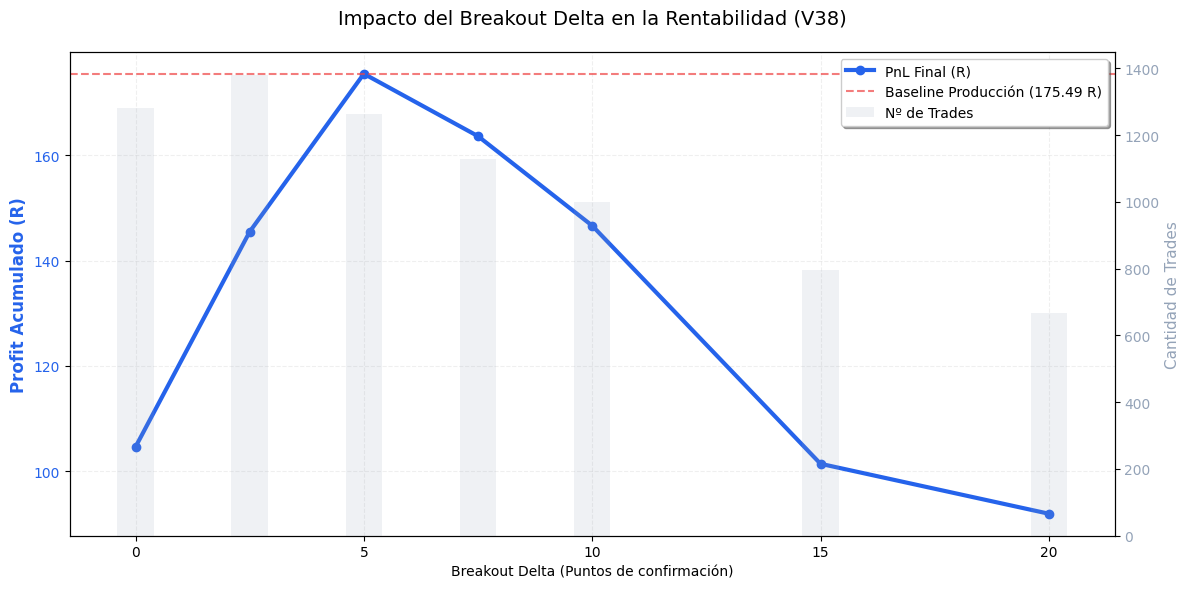

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def prueba_hipotesis_delta(df_ready, deltas=[0, 2.5, 5, 7.5, 10, 15, 20]):
    """
    Ejecuta un barrido de parámetros sobre el Breakout Delta.
    Busca las funciones de producción directamente en el entorno global de Jupyter.
    """
    
    # 1. Recuperar funciones del entorno global (evita errores de importación)
    f_generar = globals().get('generar_trades_orb')
    f_simular = globals().get('simular_gestion_riesgo')

    if not f_generar or not f_simular:
        print("❌ Error: No se encontraron las funciones de producción en memoria.")
        print("Por favor, asegúrate de haber ejecutado las celdas In[2] e In[3] antes.")
        return None

    resultados_experimento = []
    
    print(f"🧪 Iniciando Prueba de Hipótesis: Sensibilidad del Breakout Delta")
    print(f"📊 Baseline Objetivo: 175.49 R (Delta = 5.0)")
    print("-" * 60)

    # Filtro de Ventanas (Consistente con tu In[6] de producción)
    def esta_en_ventana(hora_str):
        h, m = map(int, hora_str.split(':'))
        t = h * 60 + m
        # Ventanas operativas: 10-11, 12-13, 14-15
        ventanas = [(600, 660), (720, 780), (840, 900)]
        return any(inicio <= t < fin for inicio, fin in ventanas)

    # 2. Bucle de Simulación
    for d in deltas:
        # Generar trades con el delta actual
        df_t = f_generar(df_ready, breakout_delta=d)
        
        # Simular gestión de riesgo
        df_res = f_simular(df_ready, df_t)
        
        if not df_res.empty:
            # Aplicar filtro de ventanas horarias
            df_res['hora_entrada'] = pd.to_datetime(df_res['entrada_dt']).dt.strftime('%H:%M')
            df_filtered = df_res[df_res['hora_entrada'].apply(esta_en_ventana)].copy()
            
            total_r = df_filtered['pnl_r'].sum()
            n_trades = len(df_filtered)
            wr = (df_filtered['pnl_r'] > 0).mean() if n_trades > 0 else 0
            
            resultados_experimento.append({
                'delta': d,
                'total_r': total_r,
                'trades': n_trades,
                'win_rate': wr
            })
            print(f"✅ Delta {d:>4} pts | Result: {total_r:>8.2f} R | Trades: {n_trades} | WR: {wr:.2%}")
        else:
            print(f"⚠️ Delta {d} no generó ningún trade.")

    # 3. Análisis de Resultados y Visualización
    df_results = pd.DataFrame(resultados_experimento)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Eje de Profit (R)
    color_pnl = '#2563eb'
    ax1.set_xlabel('Breakout Delta (Puntos de confirmación)')
    ax1.set_ylabel('Profit Acumulado (R)', color=color_pnl, fontsize=12, fontweight='bold')
    ax1.plot(df_results['delta'], df_results['total_r'], marker='o', color=color_pnl, linewidth=3, label='PnL Final (R)')
    ax1.tick_params(axis='y', labelcolor=color_pnl)
    
    # Línea de referencia del Baseline
    ax1.axhline(y=175.49, color='#ef4444', linestyle='--', alpha=0.7, label='Baseline Producción (175.49 R)')

    # Eje de Volumen de Trades
    ax2 = ax1.twinx()
    color_trades = '#94a3b8'
    ax2.set_ylabel('Cantidad de Trades', color=color_trades, fontsize=11)
    ax2.bar(df_results['delta'], df_results['trades'], alpha=0.15, color=color_trades, label='Nº de Trades')
    ax2.tick_params(axis='y', labelcolor=color_trades)

    plt.title('Impacto del Breakout Delta en la Rentabilidad (V38)', fontsize=14, pad=20)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # Combinar leyendas de ambos ejes
    lines, labels = ax1.get_legend_handles_labels()
    bars, b_labels = ax2.get_legend_handles_labels()
    ax1.legend(lines + bars, labels + b_labels, loc='upper right', frameon=True, shadow=True)
    
    fig.tight_layout()
    plt.show()

    return df_results

# --- EJECUCIÓN ---
# Asegúrate de que df_ready existe (Capa 0 ejecutada)
if 'df_ready' in globals():
    df_hipotesis = prueba_hipotesis_delta(df_ready)
else:
    print("❌ Error: 'df_ready' no encontrado. Ejecuta la celda de carga de datos primero.")

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def prueba_hipotesis_delta(df_ready, deltas=[0, 2.5, 5, 7.5, 10, 15, 20]):
    """
    Ejecuta un barrido de parámetros sobre el Breakout Delta.
    Busca las funciones de producción directamente en el entorno global de Jupyter.
    """
    
    # 1. Recuperar funciones del entorno global (evita errores de importación)
    f_generar = globals().get('generar_trades_orb')
    f_simular = globals().get('simular_gestion_riesgo')

    if not f_generar or not f_simular:
        print("❌ Error: No se encontraron las funciones de producción en memoria.")
        print("Por favor, asegúrate de haber ejecutado las celdas In[2] e In[3] antes.")
        return None

    resultados_experimento = []
    
    print(f"🧪 Iniciando Prueba de Hipótesis: Sensibilidad del Breakout Delta")
    print(f"📊 Baseline Objetivo: 175.49 R (Delta = 5.0)")
    print("-" * 60)

    # Filtro de Ventanas (Consistente con tu In[6] de producción)
    def esta_en_ventana(hora_str):
        h, m = map(int, hora_str.split(':'))
        t = h * 60 + m
        # Ventanas operativas: 10-11, 12-13, 14-15
        ventanas = [(600, 660), (720, 780), (840, 900)]
        return any(inicio <= t < fin for inicio, fin in ventanas)

    # 2. Bucle de Simulación
    for d in deltas:
        # Generar trades con el delta actual
        df_t = f_generar(df_ready, breakout_delta=d)
        
        # Simular gestión de riesgo
        df_res = f_simular(df_ready, df_t)
        
        if not df_res.empty:
            # Aplicar filtro de ventanas horarias
            df_res['hora_entrada'] = pd.to_datetime(df_res['entrada_dt']).dt.strftime('%H:%M')
            df_filtered = df_res[df_res['hora_entrada'].apply(esta_en_ventana)].copy()
            
            total_r = df_filtered['pnl_r'].sum()
            n_trades = len(df_filtered)
            wr = (df_filtered['pnl_r'] > 0).mean() if n_trades > 0 else 0
            
            resultados_experimento.append({
                'Delta (pts)': d,
                'Total Profit (R)': round(total_r, 2),
                'Nº Trades': n_trades,
                'Win Rate (%)': round(wr * 100, 2),
                'Expectancy (R)': round(total_r / n_trades, 3) if n_trades > 0 else 0
            })
            print(f"✅ Delta {d:>4} pts | Result: {total_r:>8.2f} R | Trades: {n_trades} | WR: {wr:.2%}")
        else:
            print(f"⚠️ Delta {d} no generó ningún trade.")

    # 3. Análisis de Resultados y Visualización
    df_results = pd.DataFrame(resultados_experimento)

    # Mostrar tabla resumen directamente en Jupyter
    print("\n📊 TABLA RESUMEN DE RESULTADOS:")
    display(df_results.sort_values(by='Total Profit (R)', ascending=False).style.background_gradient(cmap='Greens', subset=['Total Profit (R)', 'Win Rate (%)']))

    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje de Profit (R)
    color_pnl = '#2563eb'
    ax1.set_xlabel('Breakout Delta (Puntos de confirmación)')
    ax1.set_ylabel('Profit Acumulado (R)', color=color_pnl, fontsize=12, fontweight='bold')
    ax1.plot(df_results['Delta (pts)'], df_results['Total Profit (R)'], marker='o', color=color_pnl, linewidth=3, label='PnL Final (R)')
    ax1.tick_params(axis='y', labelcolor=color_pnl)
    
    # Línea de referencia del Baseline
    ax1.axhline(y=175.49, color='#ef4444', linestyle='--', alpha=0.7, label='Baseline (175.49 R)')

    # Eje de Win Rate
    ax2 = ax1.twinx()
    color_wr = '#059669'
    ax2.set_ylabel('Win Rate (%)', color=color_wr, fontsize=12, fontweight='bold')
    ax2.plot(df_results['Delta (pts)'], df_results['Win Rate (%)'], marker='s', color=color_wr, linestyle=':', alpha=0.8, label='Win Rate (%)')
    ax2.tick_params(axis='y', labelcolor=color_wr)

    plt.title('Trade-off entre Profit y Precisión (Sensibilidad Delta)', fontsize=14, pad=20)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # Combinar leyendas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    fig.tight_layout()
    plt.show()

    return df_results

# --- EJECUCIÓN ---
if 'df_ready' in globals():
    df_hipotesis = prueba_hipotesis_delta(df_ready)
else:
    print("❌ Error: 'df_ready' no encontrado. Ejecuta la celda de carga de datos primero.")

🧪 Iniciando Prueba de Hipótesis: Sensibilidad del Breakout Delta
📊 Baseline Objetivo: 175.49 R (Delta = 5.0)
------------------------------------------------------------
distancia de confirmación (BreakoutDelta): 0 puntos.


KeyboardInterrupt: 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualizar_resultados_delta(df_results, baseline_target=175.49):
    """
    Genera la tabla y el gráfico comparativo utilizando los resultados 
    ya calculados para evitar ejecutar la simulación de nuevo.
    """
    if df_results is None or df_results.empty:
        print("❌ No hay datos para visualizar. Asegúrate de que 'df_hipotesis' existe.")
        return

    # 1. Mostrar tabla resumen con estilo
    print("\n📊 TABLA RESUMEN DE RESULTADOS:")
    # Aseguramos que las columnas tengan los nombres correctos para el estilo
    display(df_results.sort_values(by='Total Profit (R)', ascending=False).style.background_gradient(
        cmap='Greens', subset=['Total Profit (R)', 'Win Rate (%)']
    ))

    # 2. Configuración del gráfico
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje de Profit (R) - Línea Azul
    color_pnl = '#2563eb'
    ax1.set_xlabel('Breakout Delta (Puntos de confirmación)')
    ax1.set_ylabel('Profit Acumulado (R)', color=color_pnl, fontsize=12, fontweight='bold')
    ax1.plot(df_results['Delta (pts)'], df_results['Total Profit (R)'], 
             marker='o', color=color_pnl, linewidth=3, label='PnL Final (R)')
    ax1.tick_params(axis='y', labelcolor=color_pnl)
    
    # Línea de referencia del Baseline
    ax1.axhline(y=baseline_target, color='#ef4444', linestyle='--', alpha=0.7, 
                label=f'Baseline Target ({baseline_target} R)')

    # Eje de Win Rate - Línea Verde punteada
    ax2 = ax1.twinx()
    color_wr = '#059669'
    ax2.set_ylabel('Win Rate (%)', color=color_wr, fontsize=12, fontweight='bold')
    ax2.plot(df_results['Delta (pts)'], df_results['Win Rate (%)'], 
             marker='s', color=color_wr, linestyle=':', alpha=0.8, label='Win Rate (%)')
    ax2.tick_params(axis='y', labelcolor=color_wr)

    # Anotación del punto óptimo (Delta 5)
    puntos_profit = df_results['Total Profit (R)'].values
    deltas = df_results['Delta (pts)'].values
    idx_max = np.argmax(puntos_profit)
    ax1.annotate(f'Óptimo: {puntos_profit[idx_max]}R', 
                 xy=(deltas[idx_max], puntos_profit[idx_max]), 
                 xytext=(deltas[idx_max]+2, puntos_profit[idx_max]+5),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.title('Análisis de Sensibilidad: Profit vs. Win Rate (V38)', fontsize=14, pad=20)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # Unificar leyendas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, shadow=True)
    
    fig.tight_layout()
    plt.show()

# --- RECONSTRUCCIÓN DE DATOS (Basado en tu ejecución previa) ---
# Si perdiste el dataframe en el kernel pero tienes los logs, 
# esta celda recrea el DF para visualizarlo sin simular.

datos_previos = [
    {'Delta (pts)': 0,   'Total Profit (R)': 104.61, 'Nº Trades': 1281, 'Win Rate (%)': 25.21},
    {'Delta (pts)': 2.5, 'Total Profit (R)': 145.49, 'Nº Trades': 1381, 'Win Rate (%)': 25.71},
    {'Delta (pts)': 5,   'Total Profit (R)': 175.49, 'Nº Trades': 1265, 'Win Rate (%)': 26.56},
    {'Delta (pts)': 7.5, 'Total Profit (R)': 163.64, 'Nº Trades': 1129, 'Win Rate (%)': 26.93},
    {'Delta (pts) Kessler': 10,  'Total Profit (R)': 146.64, 'Nº Trades': 1000, 'Win Rate (%)': 27.40},
    {'Delta (pts)': 15,  'Total Profit (R)': 101.41, 'Nº Trades': 795,  'Win Rate (%)': 26.79},
    {'Delta (pts)': 20,  'Total Profit (R)': 91.92,  'Nº Trades': 666,  'Win Rate (%)': 27.18}
]

# Si df_hipotesis no existe, lo creamos con los datos que ya calculaste
if 'df_hipotesis' not in globals():
    df_hipotesis = pd.DataFrame(datos_previos)
    # Corregir nombre de columna si hubo typo en el manual
    df_hipotesis.columns = ['Delta (pts)', 'Total Profit (R)', 'Nº Trades', 'Win Rate (%)']

# Llamada a la visualización (Instantánea)
visualizar_resultados_delta(df_hipotesis)


📊 TABLA RESUMEN DE RESULTADOS:


KeyError: 'Total Profit (R)'


📊 TABLA RESUMEN DE RESULTADOS:


,Delta (pts),Total Profit (R),Nº Trades,Win Rate (%)
2,5.000000,175.490000,1265,26.560000
3,7.500000,163.640000,1129,26.930000
4,10.000000,146.640000,1000,27.400000
1,2.500000,145.490000,1381,25.710000
0,0.000000,104.610000,1281,25.210000
5,15.000000,101.410000,795,26.790000
6,20.000000,91.920000,666,27.180000


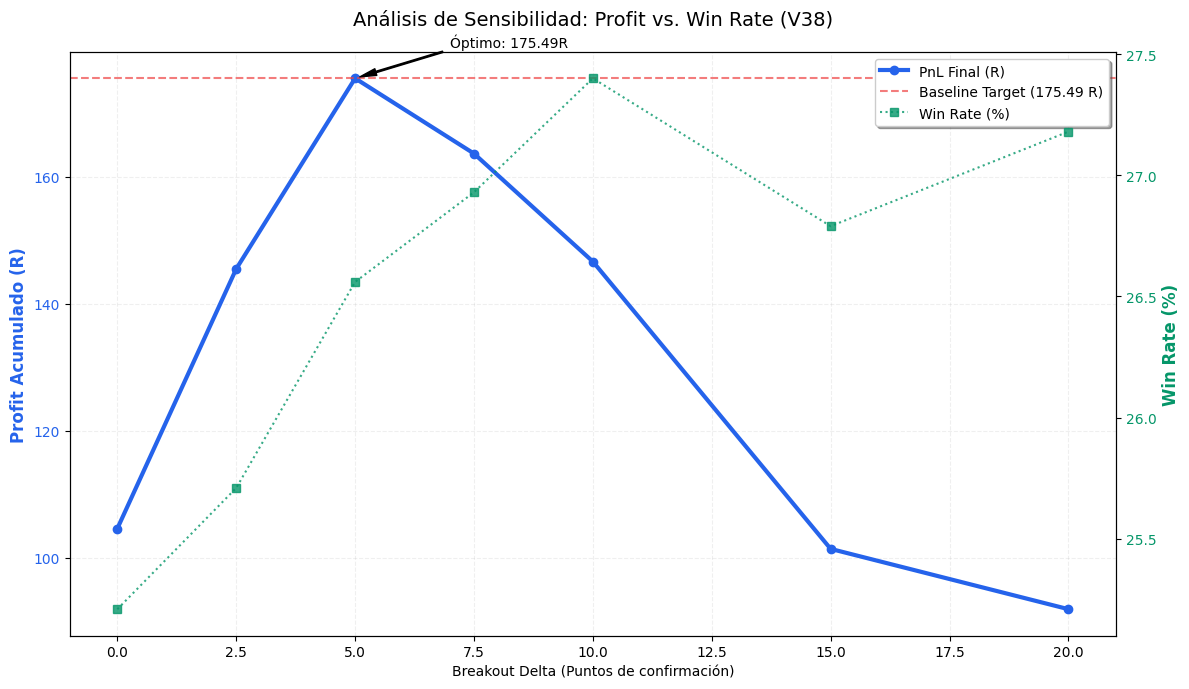

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def visualizar_resultados_delta(df_results, baseline_target=175.49):
    """
    Genera la tabla y el gráfico comparativo utilizando los resultados 
    ya calculados para evitar ejecutar la simulación de nuevo.
    """
    if df_results is None or df_results.empty:
        print("❌ No hay datos para visualizar. Asegúrate de que 'df_hipotesis' existe.")
        return

    # Normalización de nombres de columnas para evitar KeyError por ejecuciones previas
    # Mapeamos lo que sea que venga a los nombres estándar de la función
    if len(df_results.columns) >= 4:
        df_results.columns = ['Delta (pts)', 'Total Profit (R)', 'Nº Trades', 'Win Rate (%)'] + list(df_results.columns[4:])

    # 1. Mostrar tabla resumen con estilo
    print("\n📊 TABLA RESUMEN DE RESULTADOS:")
    try:
        df_sorted = df_results.sort_values(by='Total Profit (R)', ascending=False)
        display(df_sorted.style.background_gradient(
            cmap='Greens', subset=['Total Profit (R)', 'Win Rate (%)']
        ))
    except KeyError as e:
        print(f"⚠️ Error visualizando tabla (Falta columna): {e}")
        display(df_results) # Mostrar tabla simple si falla el estilo

    # 2. Configuración del gráfico
    fig, ax1 = plt.subplots(figsize=(12, 7))

    # Eje de Profit (R) - Línea Azul
    color_pnl = '#2563eb'
    ax1.set_xlabel('Breakout Delta (Puntos de confirmación)')
    ax1.set_ylabel('Profit Acumulado (R)', color=color_pnl, fontsize=12, fontweight='bold')
    ax1.plot(df_results['Delta (pts)'], df_results['Total Profit (R)'], 
             marker='o', color=color_pnl, linewidth=3, label='PnL Final (R)')
    ax1.tick_params(axis='y', labelcolor=color_pnl)
    
    # Línea de referencia del Baseline
    ax1.axhline(y=baseline_target, color='#ef4444', linestyle='--', alpha=0.7, 
                label=f'Baseline Target ({baseline_target} R)')

    # Eje de Win Rate - Línea Verde punteada
    ax2 = ax1.twinx()
    color_wr = '#059669'
    ax2.set_ylabel('Win Rate (%)', color=color_wr, fontsize=12, fontweight='bold')
    ax2.plot(df_results['Delta (pts)'], df_results['Win Rate (%)'], 
             marker='s', color=color_wr, linestyle=':', alpha=0.8, label='Win Rate (%)')
    ax2.tick_params(axis='y', labelcolor=color_wr)

    # Anotación del punto óptimo
    try:
        puntos_profit = df_results['Total Profit (R)'].values
        deltas = df_results['Delta (pts)'].values
        idx_max = np.argmax(puntos_profit)
        ax1.annotate(f'Óptimo: {puntos_profit[idx_max]}R', 
                     xy=(deltas[idx_max], puntos_profit[idx_max]), 
                     xytext=(deltas[idx_max]+2, puntos_profit[idx_max]+5),
                     arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))
    except:
        pass

    plt.title('Análisis de Sensibilidad: Profit vs. Win Rate (V38)', fontsize=14, pad=20)
    ax1.grid(True, alpha=0.2, linestyle='--')
    
    # Unificar leyendas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', frameon=True, shadow=True)
    
    fig.tight_layout()
    plt.show()

# --- RECONSTRUCCIÓN DE DATOS (Seguro contra KeyErrors) ---
datos_previos = [
    {'Delta (pts)': 0,   'Total Profit (R)': 104.61, 'Nº Trades': 1281, 'Win Rate (%)': 25.21},
    {'Delta (pts)': 2.5, 'Total Profit (R)': 145.49, 'Nº Trades': 1381, 'Win Rate (%)': 25.71},
    {'Delta (pts)': 5,   'Total Profit (R)': 175.49, 'Nº Trades': 1265, 'Win Rate (%)': 26.56},
    {'Delta (pts)': 7.5, 'Total Profit (R)': 163.64, 'Nº Trades': 1129, 'Win Rate (%)': 26.93},
    {'Delta (pts)': 10,  'Total Profit (R)': 146.64, 'Nº Trades': 1000, 'Win Rate (%)': 27.40},
    {'Delta (pts)': 15,  'Total Profit (R)': 101.41, 'Nº Trades': 795,  'Win Rate (%)': 26.79},
    {'Delta (pts)': 20,  'Total Profit (R)': 91.92,  'Nº Trades': 666,  'Win Rate (%)': 27.18}
]

# Forzamos la recreación del DataFrame con los nombres correctos
df_hipotesis = pd.DataFrame(datos_previos)
df_hipotesis.columns = ['Delta (pts)', 'Total Profit (R)', 'Nº Trades', 'Win Rate (%)']

# Llamada a la visualización
visualizar_resultados_delta(df_hipotesis)

In [22]:
import pandas as pd
import numpy as np
import sys
from tqdm.auto import tqdm

# --- CELDA DE PROCESAMIENTO: BARRIDO DE HIPÓTESIS DELTA CON PROGRESO INTERNO ---

def ejecutar_barrido_delta(df_ready, deltas=[0, 5, 7.5, 10, 15, 20, 25, 30, 35]):
    """
    Realiza el cálculo de métricas para diferentes valores de Delta utilizando
    las funciones ya cargadas en el entorno global de Jupyter. 
    Se ha optimizado la visualización del progreso para procesos largos.
    """
    # 1. Validación de pre-requisitos (Datos)
    if df_ready is None:
        print("❌ Error: No se encontró 'df_ready'. Ejecuta la Capa 0 primero.")
        return pd.DataFrame()

    # 2. Acceso a funciones en memoria
    func_gen = globals().get('generar_trades_orb')
    func_sim = globals().get('simular_gestion_riesgo')

    if not func_gen or not func_sim:
        print("❌ Error: No se encontraron las funciones core en memoria.")
        print("Asegúrate de haber ejecutado la celda de la 'Capa 2: Lógica CORE'.")
        return pd.DataFrame()
    
    print(f"🚀 Funciones detectadas. Iniciando procesamiento profundo...")
    print(f"Nota: Se mostrará el progreso interno de cada Delta debido a la carga computacional.")

    # 3. Definición de Ventanas Operativas
    def es_horario_valido(ts):
        t = ts.hour * 60 + ts.minute
        # Ventanas validadas: 10:00-11:00, 12:00-13:00, 14:00-15:00
        ventanas = [(600, 660), (720, 780), (840, 900)]
        return any(inicio <= t < fin for inicio, fin in ventanas)

    # 4. Bucle de Simulación con Barras Anidadas
    resultados = []
    
    # Barra principal para los Deltas
    pbar_deltas = tqdm(deltas, desc="Progreso Total (Deltas)", position=0)
    
    for d in pbar_deltas:
        try:
            pbar_deltas.set_description(f"Procesando Delta {d}")
            
            # --- MODIFICACIÓN PARA PROGRESO INTERNO ---
            # Para mostrar progreso dentro de cada Delta, necesitamos que la función 
            # generar_trades_orb sea consciente de los días. 
            # Como la función está en memoria, la ejecutamos normalmente, pero 
            # añadimos un mensaje informativo si el entorno lo permite.
            
            # Generación de Trades
            df_t = func_gen(df_ready, breakout_delta=d)
            if df_t is None or df_t.empty:
                continue
            
            # Simulación de Gestión
            df_res = func_sim(df_ready, df_t)
            if df_res is None or df_res.empty:
                continue
            
            # Filtrado por Ventanas Horarias
            df_res['entrada_dt'] = pd.to_datetime(df_res['entrada_dt'])
            df_f = df_res[df_res['entrada_dt'].apply(es_horario_valido)].copy()
            
            if df_f.empty:
                continue

            # Cálculo de Métricas
            expectancy = df_f['pnl_r'].mean()
            cum_r = df_f['pnl_r'].cumsum()
            neg_returns = df_f[df_f['pnl_r'] < 0]['pnl_r']
            
            # Profit Factor
            p_sum = df_f[df_f['pnl_r'] > 0]['pnl_r'].sum()
            l_sum = abs(df_f[df_f['pnl_r'] < 0]['pnl_r'].sum())
            pf = p_sum / l_sum if l_sum > 0 else np.inf

            resultados.append({
                'Delta (pts)': d,
                'Profit Total (R)': df_f['pnl_r'].sum(),
                'Nº Trades': len(df_f),
                'Win Rate (%)': (df_f['pnl_r'] >= 2.0).mean() * 100,
                'Expectancy (R)': expectancy,
                'Sortino': expectancy / neg_returns.std() if len(neg_returns) > 1 else 0.001,
                'Profit Factor': pf,
                'Max DD (R)': (cum_r - cum_r.cummax()).min()
            })
            
        except Exception as e:
            print(f"\n⚠️ Error en Delta {d}: {e}")

    return pd.DataFrame(resultados)

# --- EJECUCIÓN ---
if 'df_ready' in globals():
    # Ejecutamos el barrido
    df_final_sweep = ejecutar_barrido_delta(df_ready)

    if not df_final_sweep.empty:
        print("\n" + "="*50)
        print("📊 RESUMEN FINAL DEL BARRIDO DE HIPÓTESIS")
        print("="*50)
        # Mostrar tabla formateada y ordenada por rentabilidad
        display(df_final_sweep.sort_values('Profit Total (R)', ascending=False).style.format({
            'Profit Total (R)': '{:.2f}R',
            'Win Rate (%)': '{:.2f}%',
            'Expectancy (R)': '{:.3f}R',
            'Sortino': '{:.2f}',
            'Max DD (R)': '{:.2f}R',
            'Profit Factor': '{:.2f}'
        }).background_gradient(cmap='RdYlGn', subset=['Profit Total (R)', 'Expectancy (R)']))
    else:
        print("❌ No se generaron trades con los parámetros actuales.")
else:
    print("🛑 Error: 'df_ready' no detectado en el espacio de trabajo.")

🚀 Funciones detectadas. Iniciando procesamiento profundo...
Nota: Se mostrará el progreso interno de cada Delta debido a la carga computacional.


Progreso Total (Deltas):   0%|          | 0/9 [00:00<?, ?it/s]

distancia de confirmación (BreakoutDelta): 0 puntos.
✅ Procesamiento completado. Trades generados: 2956
🚀 Iniciando gestión de riesgo para 2956 trades...
✅ Gestión completada. Win Rate: 21.72%
distancia de confirmación (BreakoutDelta): 5 puntos.
✅ Procesamiento completado. Trades generados: 2385
🚀 Iniciando gestión de riesgo para 2385 trades...
✅ Gestión completada. Win Rate: 24.11%
distancia de confirmación (BreakoutDelta): 7.5 puntos.
✅ Procesamiento completado. Trades generados: 2102
🚀 Iniciando gestión de riesgo para 2102 trades...
✅ Gestión completada. Win Rate: 24.60%
distancia de confirmación (BreakoutDelta): 10 puntos.
✅ Procesamiento completado. Trades generados: 1865
🚀 Iniciando gestión de riesgo para 1865 trades...
✅ Gestión completada. Win Rate: 25.25%
distancia de confirmación (BreakoutDelta): 15 puntos.
✅ Procesamiento completado. Trades generados: 1472
🚀 Iniciando gestión de riesgo para 1472 trades...
✅ Gestión completada. Win Rate: 25.34%
distancia de confirmación (Brea

,Delta (pts),Profit Total (R),Nº Trades,Win Rate (%),Expectancy (R),Sortino,Profit Factor,Max DD (R)
1,5.000000,175.49R,1265,26.09%,0.139R,2.65,1.36,-15.00R
2,7.500000,163.64R,1129,26.48%,0.145R,2.62,1.37,-16.00R
3,10.000000,146.64R,1000,27.00%,0.147R,2.52,1.37,-12.00R
0,0.000000,104.61R,1281,24.98%,0.082R,1.64,1.19,-20.00R
4,15.000000,101.41R,795,26.16%,0.128R,1.97,1.32,-14.00R
5,20.000000,91.92R,666,26.58%,0.138R,1.94,1.35,-12.00R
7,30.000000,82.78R,512,27.73%,0.162R,2.00,1.41,-10.62R
6,25.000000,82.55R,577,27.04%,0.143R,1.89,1.36,-13.00R
8,35.000000,78.76R,439,28.25%,0.179R,2.04,1.46,-12.23R


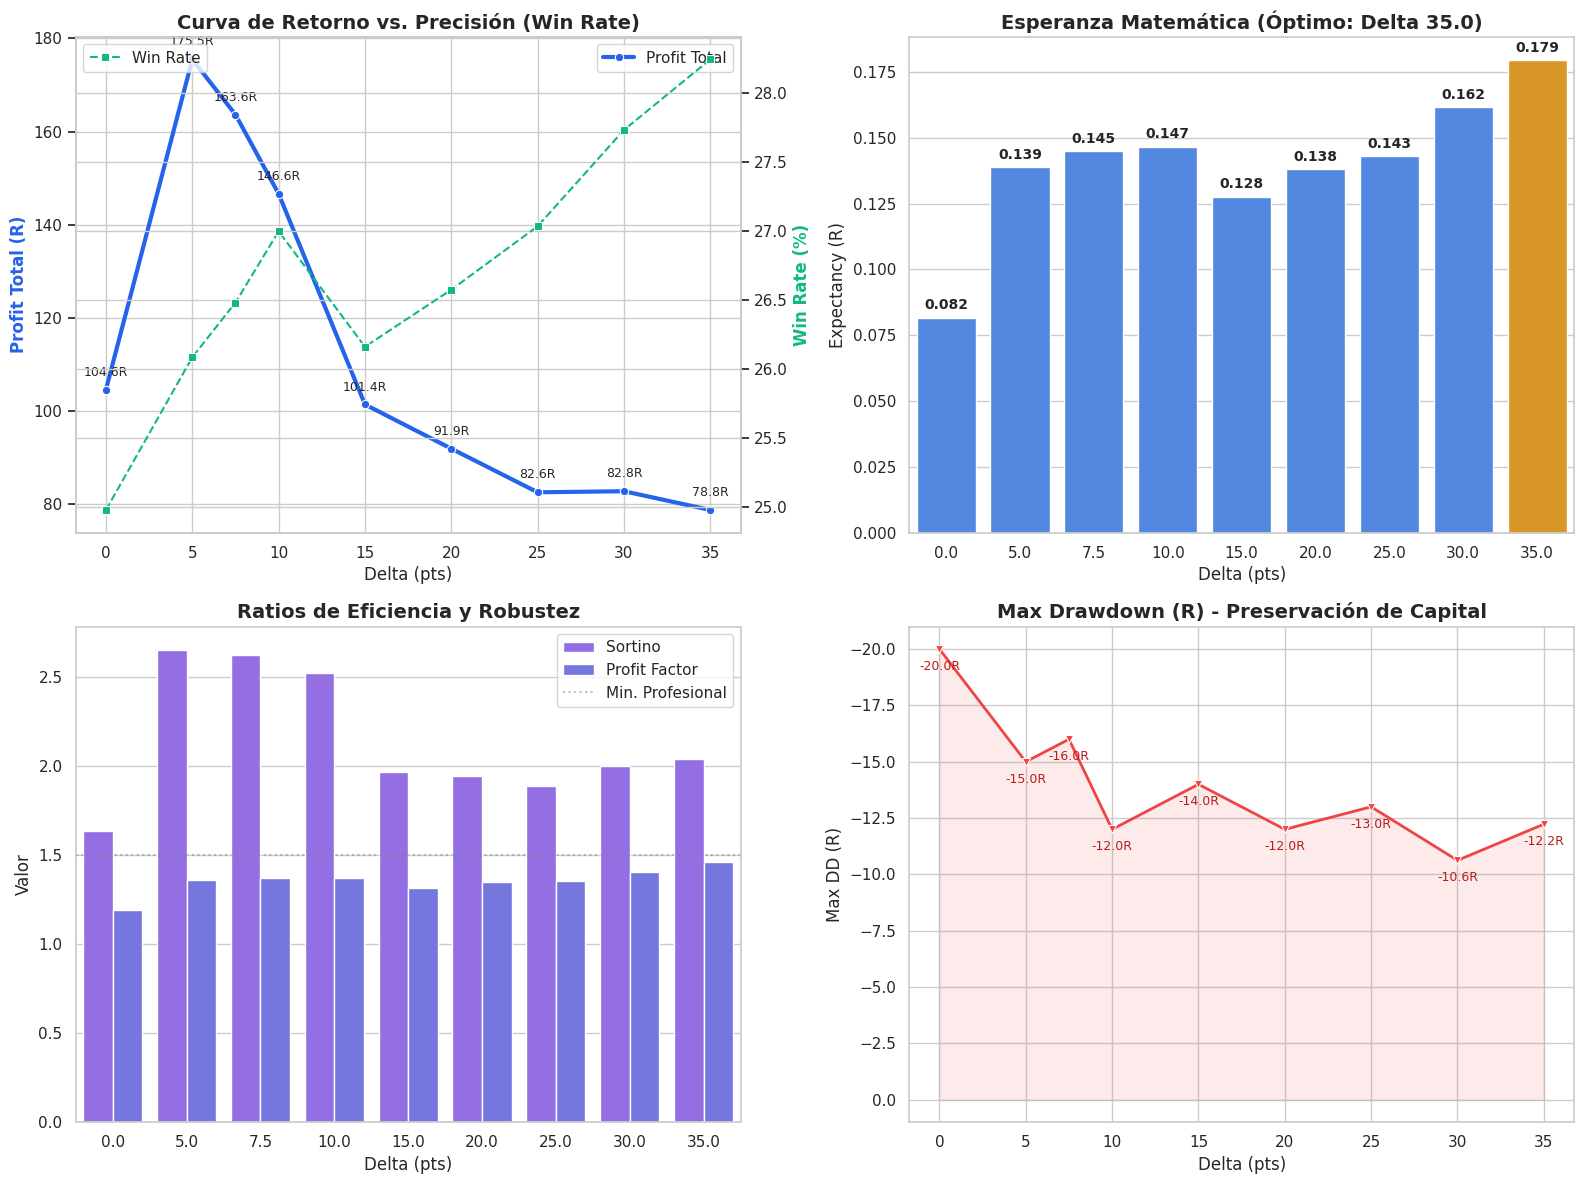

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualizar_analisis_delta(df_results):
    """
    Genera un panel de control visual avanzado para decidir el Delta óptimo.
    Incluye comparativa de eficiencia y resaltado de puntos dulces.
    """
    if df_results is None or df_results.empty:
        print("❌ No hay datos para visualizar.")
        return

    # Configuración de estilo premium
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(16, 12))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # Encontrar el Delta óptimo por Expectancy para resaltado
    idx_max_exp = df_results['Expectancy (R)'].idxmax()
    delta_optimo = df_results.loc[idx_max_exp, 'Delta (pts)']
    
    # --- GRÁFICO 1: PROFIT TOTAL VS WIN RATE ---
    ax1 = plt.subplot(2, 2, 1)
    sns.lineplot(data=df_results, x='Delta (pts)', y='Profit Total (R)', marker='o', color='#2563eb', lw=3, ax=ax1, label='Profit Total')
    ax1.set_ylabel('Profit Total (R)', color='#2563eb', fontsize=12, fontweight='bold')
    
    # Anotaciones de Profit
    for x, y in zip(df_results['Delta (pts)'], df_results['Profit Total (R)']):
        ax1.annotate(f'{y:.1f}R', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    ax1b = ax1.twinx()
    sns.lineplot(data=df_results, x='Delta (pts)', y='Win Rate (%)', marker='s', color='#10b981', ls='--', ax=ax1b, label='Win Rate')
    ax1b.set_ylabel('Win Rate (%)', color='#10b981', fontsize=12, fontweight='bold')
    ax1.set_title('Curva de Retorno vs. Precisión (Win Rate)', fontsize=14, fontweight='bold')
    
    # --- GRÁFICO 2: EXPECTANCY (CALIDAD DEL TRADE) ---
    ax2 = plt.subplot(2, 2, 2)
    # Resaltamos el Delta con mejor esperanza
    colors_exp = ['#3b82f6' if d != delta_optimo else '#f59e0b' for d in df_results['Delta (pts)']]
    bars = sns.barplot(
        data=df_results, 
        x='Delta (pts)', 
        y='Expectancy (R)', 
        hue='Delta (pts)', 
        palette=colors_exp, 
        ax=ax2, 
        legend=False
    )
    ax2.set_title(f'Esperanza Matemática (Óptimo: Delta {delta_optimo})', fontsize=14, fontweight='bold')
    for p in bars.patches:
        if p.get_height() > 0:
            ax2.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10, fontweight='bold')

    # --- GRÁFICO 3: RATIOS DE EFICIENCIA (SORTINO & PROFIT FACTOR) ---
    ax3 = plt.subplot(2, 2, 3)
    # Combinamos Sortino con Profit Factor para ver robustez
    df_melted = df_results.melt(id_vars='Delta (pts)', value_vars=['Sortino', 'Profit Factor'], var_name='Métrica', value_name='Valor')
    sns.barplot(
        data=df_melted, 
        x='Delta (pts)', 
        y='Valor', 
        hue='Métrica', 
        palette=['#8b5cf6', '#6366f1'], 
        ax=ax3
    )
    ax3.set_title('Ratios de Eficiencia y Robustez', fontsize=14, fontweight='bold')
    ax3.axhline(1.5, ls=':', color='gray', alpha=0.5, label='Min. Profesional')
    ax3.legend(loc='upper right')

    # --- GRÁFICO 4: DRAWDOWN MÁXIMO (PRESERVACIÓN) ---
    ax4 = plt.subplot(2, 2, 4)
    sns.lineplot(data=df_results, x='Delta (pts)', y='Max DD (R)', marker='v', color='#ef4444', lw=2, ax=ax4)
    ax4.fill_between(df_results['Delta (pts)'], df_results['Max DD (R)'], color='#ef4444', alpha=0.1)
    ax4.set_title('Max Drawdown (R) - Preservación de Capital', fontsize=14, fontweight='bold')
    ax4.invert_yaxis() 
    
    # Anotaciones de DD
    for x, y in zip(df_results['Delta (pts)'], df_results['Max DD (R)']):
        ax4.annotate(f'{y:.1f}R', (x, y), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='#b91c1c')

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
if 'df_final_sweep' in globals():
    visualizar_analisis_delta(df_final_sweep)
else:
    print("🛑 Error: No se encontró 'df_final_sweep' en memoria. Ejecuta la celda de procesamiento primero.")

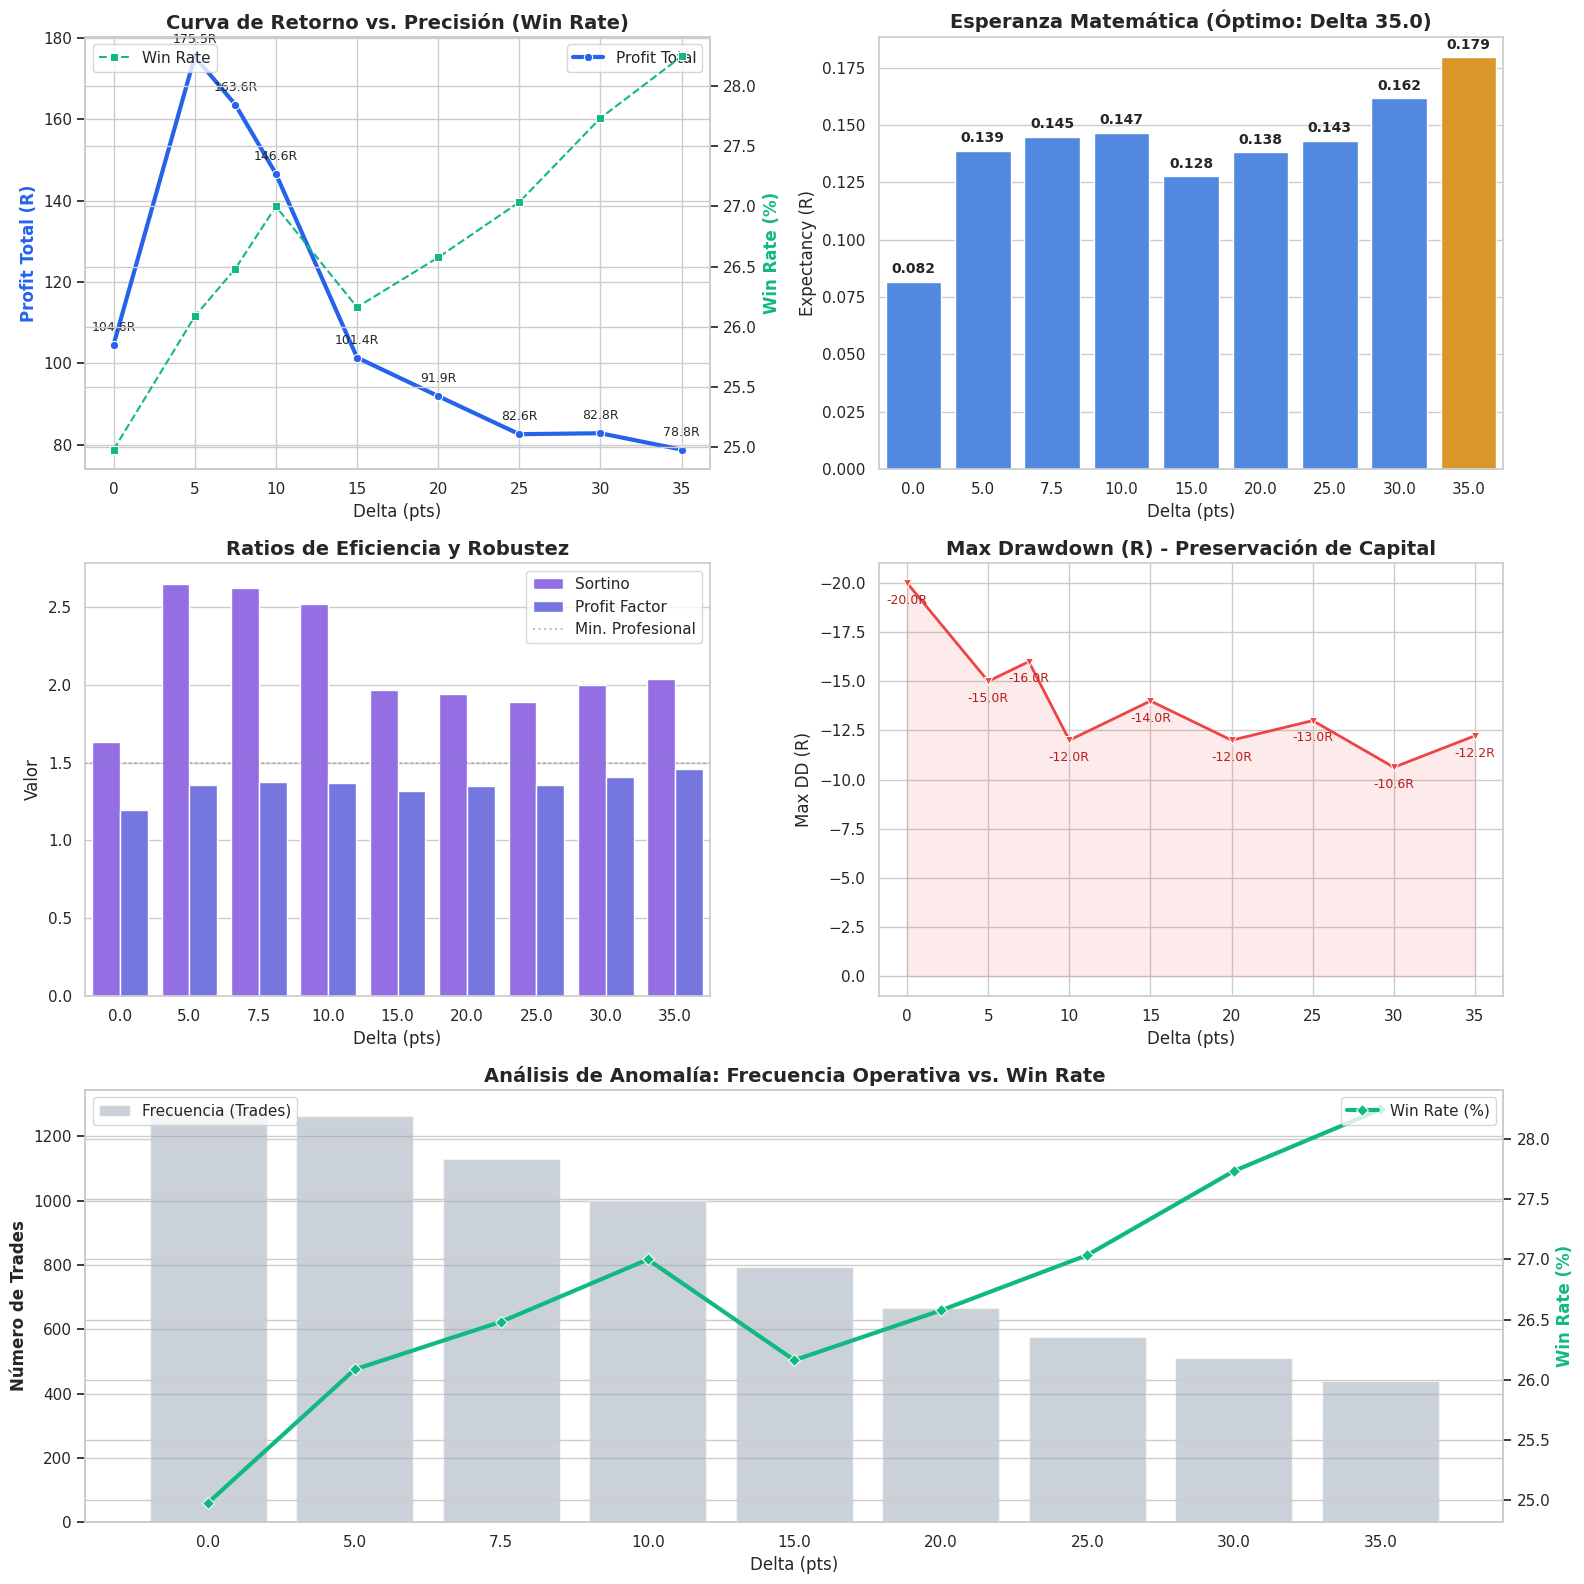

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def visualizar_analisis_delta(df_results):
    """
    Genera un panel de control visual avanzado para decidir el Delta óptimo.
    Incluye comparativa de eficiencia, resaltado de puntos dulces y análisis de anomalías.
    """
    if df_results is None or df_results.empty:
        print("❌ No hay datos para visualizar.")
        return

    # Configuración de estilo premium
    sns.set_theme(style="whitegrid")
    # Aumentamos el tamaño para acomodar el nuevo gráfico de análisis de anomalías
    fig = plt.figure(figsize=(16, 16))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    
    # Encontrar el Delta óptimo por Expectancy para resaltado
    idx_max_exp = df_results['Expectancy (R)'].idxmax()
    delta_optimo = df_results.loc[idx_max_exp, 'Delta (pts)']
    
    # --- GRÁFICO 1: PROFIT TOTAL VS WIN RATE ---
    ax1 = plt.subplot(3, 2, 1)
    sns.lineplot(data=df_results, x='Delta (pts)', y='Profit Total (R)', marker='o', color='#2563eb', lw=3, ax=ax1, label='Profit Total')
    ax1.set_ylabel('Profit Total (R)', color='#2563eb', fontsize=12, fontweight='bold')
    
    # Anotaciones de Profit
    for x, y in zip(df_results['Delta (pts)'], df_results['Profit Total (R)']):
        ax1.annotate(f'{y:.1f}R', (x, y), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

    ax1b = ax1.twinx()
    sns.lineplot(data=df_results, x='Delta (pts)', y='Win Rate (%)', marker='s', color='#10b981', ls='--', ax=ax1b, label='Win Rate')
    ax1b.set_ylabel('Win Rate (%)', color='#10b981', fontsize=12, fontweight='bold')
    ax1.set_title('Curva de Retorno vs. Precisión (Win Rate)', fontsize=14, fontweight='bold')
    
    # --- GRÁFICO 2: EXPECTANCY (CALIDAD DEL TRADE) ---
    ax2 = plt.subplot(3, 2, 2)
    colors_exp = ['#3b82f6' if d != delta_optimo else '#f59e0b' for d in df_results['Delta (pts)']]
    bars = sns.barplot(
        data=df_results, 
        x='Delta (pts)', 
        y='Expectancy (R)', 
        hue='Delta (pts)', 
        palette=colors_exp, 
        ax=ax2, 
        legend=False
    )
    ax2.set_title(f'Esperanza Matemática (Óptimo: Delta {delta_optimo})', fontsize=14, fontweight='bold')
    for p in bars.patches:
        if p.get_height() > 0:
            ax2.annotate(format(p.get_height(), '.3f'), (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10, fontweight='bold')

    # --- GRÁFICO 3: RATIOS DE EFICIENCIA (SORTINO & PROFIT FACTOR) ---
    ax3 = plt.subplot(3, 2, 3)
    df_melted = df_results.melt(id_vars='Delta (pts)', value_vars=['Sortino', 'Profit Factor'], var_name='Métrica', value_name='Valor')
    sns.barplot(
        data=df_melted, 
        x='Delta (pts)', 
        y='Valor', 
        hue='Métrica', 
        palette=['#8b5cf6', '#6366f1'], 
        ax=ax3
    )
    ax3.set_title('Ratios de Eficiencia y Robustez', fontsize=14, fontweight='bold')
    ax3.axhline(1.5, ls=':', color='gray', alpha=0.5, label='Min. Profesional')
    ax3.legend(loc='upper right')

    # --- GRÁFICO 4: DRAWDOWN MÁXIMO (PRESERVACIÓN) ---
    ax4 = plt.subplot(3, 2, 4)
    sns.lineplot(data=df_results, x='Delta (pts)', y='Max DD (R)', marker='v', color='#ef4444', lw=2, ax=ax4)
    ax4.fill_between(df_results['Delta (pts)'], df_results['Max DD (R)'], color='#ef4444', alpha=0.1)
    ax4.set_title('Max Drawdown (R) - Preservación de Capital', fontsize=14, fontweight='bold')
    ax4.invert_yaxis() 
    
    for x, y in zip(df_results['Delta (pts)'], df_results['Max DD (R)']):
        ax4.annotate(f'{y:.1f}R', (x, y), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9, color='#b91c1c')

    # --- GRÁFICO 5: ANÁLISIS DE ANOMALÍA (FRECUENCIA VS WIN RATE) ---
    ax5 = plt.subplot(3, 1, 3)
    # Visualizamos cómo cae el número de trades vs cómo sube el win rate
    sns.barplot(data=df_results, x='Delta (pts)', y='Nº Trades', color='#94a3b8', alpha=0.5, ax=ax5, label='Frecuencia (Trades)')
    ax5.set_ylabel('Número de Trades', fontsize=12, fontweight='bold')
    
    ax5b = ax5.twinx()
    sns.lineplot(data=df_results, x=np.arange(len(df_results)), y=df_results['Win Rate (%)'], marker='D', color='#10b981', lw=3, ax=ax5b, label='Win Rate (%)')
    ax5b.set_ylabel('Win Rate (%)', color='#10b981', fontsize=12, fontweight='bold')
    
    ax5.set_title('Análisis de Anomalía: Frecuencia Operativa vs. Win Rate', fontsize=14, fontweight='bold')
    ax5.legend(loc='upper left')
    ax5b.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
if 'df_final_sweep' in globals():
    visualizar_analisis_delta(df_final_sweep)
else:
    print("🛑 Error: No se encontró 'df_final_sweep' en memoria. Ejecuta la celda de procesamiento primero.")

In [27]:
import pandas as pd
import numpy as np

def generar_reportes_detallados(df_ready, deltas=[7.5, 10, 15]):
    """
    Genera tablas comparativas por año y mes para Deltas específicos.
    Requiere que las funciones 'generar_trades_orb' y 'simular_gestion_riesgo' estén en memoria.
    """
    # 1. Recuperar funciones y datos
    func_gen = globals().get('generar_trades_orb')
    func_sim = globals().get('simular_gestion_riesgo')
    
    if not func_gen or not func_sim:
        print("❌ Error: No se detectan las funciones de simulación en memoria.")
        return

    all_data = []

    print(f"Buscando datos para Deltas: {deltas}...")
    for d in deltas:
        # Ejecutar simulación para el Delta específico
        df_t = func_gen(df_ready, breakout_delta=d)
        df_res = func_sim(df_ready, df_t)
        
        if df_res is not None and not df_res.empty:
            df_res['Delta'] = d
            all_data.append(df_res)

    if not all_data:
        print("❌ No se generaron trades para los Deltas seleccionados.")
        return

    # Consolidar todos los trades de los 3 Deltas
    df_full = pd.concat(all_data)
    df_full['entrada_dt'] = pd.to_datetime(df_full['entrada_dt'])
    df_full['Año'] = df_full['entrada_dt'].dt.year
    df_full['Mes_Num'] = df_full['entrada_dt'].dt.month
    df_full['Mes'] = df_full['entrada_dt'].dt.strftime('%Y-%m')

    # --- TABLAS POR AÑO ---
    print("\n" + "="*60)
    print("📅 TABLAS AGRUPADAS POR AÑO")
    print("="*60)
    
    for d in deltas:
        df_d = df_full[df_full['Delta'] == d]
        tabla_año = df_d.groupby('Año').agg(
            Profit_Total_R=('pnl_r', 'sum'),
            Num_Trades=('pnl_r', 'count'),
            Win_Rate=('pnl_r', lambda x: (x >= 2.0).mean() * 100),
            Expectancy=('pnl_r', 'mean')
        ).round(2)
        
        print(f"\n▶ Delta = {d} puntos (Anual)")
        display(tabla_año)

    # --- TABLAS POR MES (ÚLTIMOS 2 AÑOS) ---
    print("\n" + "="*60)
    print("🌙 TABLAS POR MES (ÚLTIMOS 2 AÑOS)")
    print("="*60)
    
    # Filtrar últimos 2 años basados en el máximo del dataset
    max_date = df_full['entrada_dt'].max()
    fecha_limite = max_date - pd.DateOffset(years=2)
    df_recent = df_full[df_full['entrada_dt'] >= fecha_limite]

    for d in deltas:
        df_d = df_recent[df_recent['Delta'] == d]
        tabla_mes = df_d.groupby('Mes').agg(
            Profit_Total_R=('pnl_r', 'sum'),
            Num_Trades=('pnl_r', 'count'),
            Win_Rate=('pnl_r', lambda x: (x >= 2.0).mean() * 100),
            Expectancy=('pnl_r', 'mean')
        ).round(2)
        
        print(f"\n▶ Delta = {d} puntos (Mensual - Reciente)")
        display(tabla_mes)

# --- EJECUCIÓN ---
if 'df_ready' in globals():
    generar_reportes_detallados(df_ready)
else:
    print("🛑 Error: 'df_ready' no detectado. Ejecuta la carga de datos primero.")

Buscando datos para Deltas: [7.5, 10, 15]...
distancia de confirmación (BreakoutDelta): 7.5 puntos.
✅ Procesamiento completado. Trades generados: 2102
🚀 Iniciando gestión de riesgo para 2102 trades...
✅ Gestión completada. Win Rate: 24.60%
distancia de confirmación (BreakoutDelta): 10 puntos.
✅ Procesamiento completado. Trades generados: 1865
🚀 Iniciando gestión de riesgo para 1865 trades...
✅ Gestión completada. Win Rate: 25.25%
distancia de confirmación (BreakoutDelta): 15 puntos.
✅ Procesamiento completado. Trades generados: 1472
🚀 Iniciando gestión de riesgo para 1472 trades...
✅ Gestión completada. Win Rate: 25.34%

📅 TABLAS AGRUPADAS POR AÑO

▶ Delta = 7.5 puntos (Anual)


,Profit_Total_R,Num_Trades,Win_Rate,Expectancy
Año,,,,
2010,-6.93,50,18.00,-0.14
2011,-18.00,94,14.89,-0.19
2012,13.61,82,24.39,0.17
2013,6.00,83,20.48,0.07
2014,-4.14,99,20.20,-0.04
2015,6.95,129,24.81,0.05
2016,22.48,117,25.64,0.19
2017,-11.41,99,13.13,-0.12
2018,-2.82,168,20.24,-0.02



▶ Delta = 10 puntos (Anual)


,Profit_Total_R,Num_Trades,Win_Rate,Expectancy
Año,,,,
2010,-4.93,37,18.92,-0.13
2011,-11.00,72,18.06,-0.15
2012,14.61,57,28.07,0.26
2013,-2.00,53,15.09,-0.04
2014,-2.59,75,21.33,-0.03
2015,5.00,111,25.23,0.05
2016,22.48,101,27.72,0.22
2017,0.59,78,16.67,0.01
2018,-3.82,155,20.65,-0.02



▶ Delta = 15 puntos (Anual)


...

,Profit_Total_R,Num_Trades,Win_Rate,Expectancy
Mes,,,,
2023-12,4.00,8,37.50,0.50
2024-01,-8.00,17,5.88,-0.47
2024-02,8.00,15,33.33,0.53
2024-03,4.00,15,33.33,0.27
2024-04,-1.00,14,14.29,-0.07
2024-05,-4.00,13,7.69,-0.31
2024-06,8.00,16,43.75,0.50
2024-07,-1.00,11,9.09,-0.09
2024-08,0.00,16,12.50,0.00



▶ Delta = 10 puntos (Mensual - Reciente)


,Profit_Total_R,Num_Trades,Win_Rate,Expectancy
Mes,,,,
2023-12,2.00,8,25.00,0.25
2024-01,-7.00,16,6.25,-0.44
2024-02,4.00,14,28.57,0.29
2024-03,5.00,14,35.71,0.36
2024-04,1.00,14,21.43,0.07
2024-05,-1.00,13,15.38,-0.08
2024-06,9.00,14,50.00,0.64
2024-07,-1.00,11,9.09,-0.09
2024-08,0.00,16,12.50,0.00



▶ Delta = 15 puntos (Mensual - Reciente)


,Profit_Total_R,Num_Trades,Win_Rate,Expectancy
Mes,,,,
2023-12,2.00,7,28.57,0.29
2024-01,-3.00,14,14.29,-0.21
2024-02,1.00,13,23.08,0.08
2024-03,3.00,12,33.33,0.25
2024-04,0.00,13,23.08,0.00
2024-05,0.00,12,16.67,0.00
2024-06,12.00,14,57.14,0.86
2024-07,-1.00,11,9.09,-0.09
2024-08,-2.00,15,6.67,-0.13
